# 1. Dataset y Estructura

Los pacientes diabéticos hospitalizados presentan tasas de readmisión elevadas. Cuando el reingreso ocurre dentro de los 30 días posteriores al alta, los sistemas de salud lo interpretan como un indicador de calidad asistencial, porque sugiere un alta prematura, una estabilización incompleta o una planificación deficiente del egreso. El objetivo del proyecto es predecir ese reingreso temprano con la información disponible en el momento del alta.

## 1.1. Dataset

- **Nombre:** Diabetes 130-US Hospitals for Years 1999-2008
- **Fuente:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)
- **Tamaño:** 101,766 registros y 50 variables
- **Unidad de observación:** el **encuentro hospitalario**, no el paciente
- **Criterios de inclusión originales:** ingresos de pacientes con diagnóstico de diabetes, estancia de 1 a 14 días, con pruebas de laboratorio realizadas y medicamentos administrados durante la hospitalización
- **Archivo auxiliar:** `IDS_mapping.csv`, que traduce los tres identificadores administrativos codificados como enteros


## 1.2. Diccionario de variables

El dataset contiene variables de distinta naturaleza que permiten caracterizar a los pacientes, sus antecedentes, las condiciones clínicas y el desarrollo de la hospitalización. Para organizar estas variables, se clasifican según su **bloque temático o naturaleza** y su función dentro del problema de aprendizaje supervisado: **variables predictoras** y **variable objetivo**.

Las variables predictoras corresponden a las características utilizadas como entradas potenciales del modelo para identificar patrones asociados al reingreso hospitalario. La variable objetivo, por su parte, representa el desenlace que se busca predecir: la readmisión del paciente dentro de los 30 días posteriores al alta.

| Variable                   | Descripción                                                                                                                               | Bloque o naturaleza  | Función              |
| -------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | -------------------- | -------------------- |
| `encounter_id`             | Identificador del encuentro hospitalario, asignado de forma secuencial                                                                    | Administrativa       | Predictora potencial |
| `patient_nbr`              | Identificador del paciente; se repite entre encuentros del mismo individuo                                                                | Administrativa       | Predictora potencial |
| `race`                     | Raza autodeclarada                                                                                                                        | Demográfica          | Predictora           |
| `gender`                   | Sexo registrado                                                                                                                           | Demográfica          | Predictora           |
| `age`                      | Edad agrupada en intervalos de diez años                                                                                                  | Demográfica          | Predictora           |
| `weight`                   | Peso en intervalos de libras                                                                                                              | Clínica              | Predictora           |
| `admission_type_id`        | Tipo de admisión: urgencia, electiva, recién nacido, entre otros                                                                          | Administrativa       | Predictora           |
| `discharge_disposition_id` | Destino al alta: domicilio, traslado a otra institución, fallecimiento, hospicio                                                          | Administrativa       | Predictora potencial |
| `admission_source_id`      | Vía de ingreso: urgencias, remisión médica, traslado desde otro centro                                                                    | Administrativa       | Predictora           |
| `time_in_hospital`         | Días transcurridos entre el ingreso y el alta (1 a 14 por criterio de inclusión)                                                          | Proceso hospitalario | Predictora           |
| `payer_code`               | Código del asegurador responsable del pago                                                                                                | Administrativa       | Predictora           |
| `medical_specialty`        | Especialidad del médico que admite al paciente                                                                                            | Administrativa       | Predictora           |
| `num_lab_procedures`       | Pruebas de laboratorio realizadas durante el ingreso                                                                                      | Proceso hospitalario | Predictora           |
| `num_procedures`           | Procedimientos distintos de laboratorio realizados durante el ingreso                                                                     | Proceso hospitalario | Predictora           |
| `num_medications`          | Medicamentos distintos administrados durante el ingreso                                                                                   | Proceso hospitalario | Predictora           |
| `number_outpatient`        | Consultas externas del paciente en el año previo al encuentro                                                                             | Historial clínico    | Predictora           |
| `number_emergency`         | Visitas a urgencias del paciente en el año previo al encuentro                                                                            | Historial clínico    | Predictora           |
| `number_inpatient`         | Hospitalizaciones del paciente en el año previo al encuentro                                                                              | Historial clínico    | Predictora           |
| `diag_1`                   | Diagnóstico principal, codificado en ICD-9                                                                                                | Clínica              | Predictora           |
| `diag_2`                   | Diagnóstico secundario, codificado en ICD-9                                                                                               | Clínica              | Predictora           |
| `diag_3`                   | Diagnóstico adicional, codificado en ICD-9                                                                                                | Clínica              | Predictora           |
| `number_diagnoses`         | Número de diagnósticos registrados en el episodio                                                                                         | Clínica              | Predictora           |
| `max_glu_serum`            | Glucosa sérica máxima: `>200`, `>300`, `Norm` o prueba no realizada                                                                       | Laboratorio          | Predictora           |
| `A1Cresult`                | Hemoglobina glicosilada: `>7`, `>8`, `Norm` o prueba no realizada                                                                         | Laboratorio          | Predictora           |
| 23 columnas de fármacos    | Estado de cada antidiabético durante el ingreso: `No` (no administrado), `Steady` (dosis mantenida), `Up` (aumentada) o `Down` (reducida) | Tratamiento          | Predictora           |
| `change`                   | Indica si hubo algún cambio en la medicación antidiabética                                                                                | Tratamiento          | Predictora           |
| `diabetesMed`              | Indica si se administró algún medicamento antidiabético                                                                                   | Tratamiento          | Predictora           |
| `readmitted`               | Readmisión posterior al alta: `<30` días, `>30` días o ninguna                                                                            | Desenlace            | **Objetivo**         |

Las 23 columnas de fármacos son `metformin`, `repaglinide`, `nateglinide`, `chlorpropamide`, `glimepiride`, `acetohexamide`, `glipizide`, `glyburide`, `tolbutamide`, `pioglitazone`, `rosiglitazone`, `acarbose`, `miglitol`, `troglitazone`, `tolazamide`, `examide`, `citoglipton`, `insulin`, `glyburide-metformin`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone` y `metformin-pioglitazone`.


## 1.3. Variable objetivo

La variable `readmitted` tiene tres niveles: `<30`, `>30` y `NO`. Se derivará la variable binaria

$$
y_i = \begin{cases}
1 & \text{si el paciente } i \text{ reingresa antes de 30 días tras el alta} \\
0 & \text{en caso contrario}
\end{cases}
$$

Las readmisiones posteriores a 30 días se agrupan con los no readmitidos porque responden sobre todo a la progresión natural de una enfermedad crónica y no a la calidad del episodio analizado.

In [1]:
from config import *

## 2. Lectura de datos faltantes

El archivo usa dos convenciones distintas:

1. El carácter `?` indica un **dato ausente**. Se convierte a `NaN`.
2. El valor `None` en `A1Cresult` y `max_glu_serum` indica que **la prueba no se realizó**. No es un dato perdido: es una decisión clínica, y como tal es informativa. Se conserva como categoría.

Por defecto `pandas` interpreta la cadena `"None"` como nulo, lo que borraría esa distinción. Se desactiva ese comportamiento con `keep_default_na=False` y se declara `?` como único código de faltante.

In [2]:
crudo = pd.read_csv(
    DATOS_CRUDOS / "diabetic_data.csv",
    na_values=["?"],
    keep_default_na=False,
    low_memory=False,
)

print(f"Registros        : {crudo.shape[0]:,}")
print(f"Variables        : {crudo.shape[1]}")
print(f"Encuentros únicos: {crudo['encounter_id'].nunique():,}")
print(f"Pacientes únicos : {crudo['patient_nbr'].nunique():,}")

Registros        : 101,766
Variables        : 50
Encuentros únicos: 101,766
Pacientes únicos : 71,518


In [7]:
tabla(crudo.head(), filas=5)

In [5]:
tabla(crudo.tail(), filas=5)

In [9]:
resumen = pd.DataFrame({
    "Variable": crudo.columns,
    "Tipo de dato": crudo.dtypes.astype(str).values,
    "Valores no nulos": crudo.notna().sum().values,
    "Valores faltantes": crudo.isna().sum().values,
    "Valores únicos": crudo.nunique().values
})

tabla(resumen, filas=15)

In [10]:
tabla(
    crudo
    .select_dtypes(include="number")
    .drop(columns=[
        "encounter_id",
        "patient_nbr",
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id"
    ])
    .describe()
    .T
    .round(2),
    filas=20
)

Tres observaciones de esta primera lectura:

- Trece variables son numéricas, pero tres de ellas (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) son **códigos categóricos**.
- Las variables de utilización previa (`number_outpatient`, `number_emergency`, `number_inpatient`) tienen mediana cero y máximos altos, patrón típico de conteos con exceso de ceros.
- `weight` aparece con cobertura mínima.

### 2.1. Rangos y valores imposibles

Se verifica que ninguna variable numérica contenga valores lógicamente inadmisibles, ni códigos centinela del tipo 999 o 9999 que suelen usarse para marcar ausencias.

In [11]:
NUMERICAS_CRUDAS = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]

rangos = pd.DataFrame({
    "mínimo": crudo[NUMERICAS_CRUDAS].min(),
    "máximo": crudo[NUMERICAS_CRUDAS].max(),
    "negativos": (crudo[NUMERICAS_CRUDAS] < 0).sum(),
    "posibles centinelas (999 / 9999)": [
        crudo[c].isin([999, 9999, 99999]).sum() for c in NUMERICAS_CRUDAS
    ],
})
rangos

,mínimo,máximo,negativos,posibles centinelas (999 / 9999)
time_in_hospital,1,14,0,0
num_lab_procedures,1,132,0,0
num_procedures,0,6,0,0
num_medications,1,81,0,0
number_outpatient,0,42,0,0
number_emergency,0,76,0,0
number_inpatient,0,21,0,0
number_diagnoses,1,16,0,0


No hay valores negativos ni códigos centinela. `time_in_hospital` va de 1 a 14 días, coherente con los criterios de inclusión declarados por los autores del dataset, y el resto de rangos es clínicamente plausible. A diferencia de otros conjuntos administrativos, aquí no se requiere limpieza de valores imposibles.

## 3. Diccionario de identificadores administrativos

`IDS_mapping.csv` apila tres tablas en un solo archivo, separadas por líneas vacías.

In [12]:
def cargar_mapeo_ids(ruta):
    """Separa las tres tablas apiladas en IDS_mapping.csv.

    El archivo contiene, en secuencia, la traducción de admission_type_id,
    discharge_disposition_id y admission_source_id, cada una precedida por su
    propia línea de encabezado y separada por una línea vacía.

    Parameters
    ----------
    ruta : str or pathlib.Path
        Ruta al archivo IDS_mapping.csv.

    Returns
    -------
    dict
        Diccionario {nombre_columna: {código: descripción}}.
    """
    mapeos, clave = {}, None
    for linea in Path(ruta).read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea == ",":
            continue
        if linea.endswith("_id,description"):
            clave = linea.split(",")[0]
            mapeos[clave] = {}
            continue
        codigo, _, descripcion = linea.partition(",")
        if clave is not None and codigo.isdigit():
            mapeos[clave][int(codigo)] = descripcion.strip('"')
    return mapeos


mapeos = cargar_mapeo_ids(DATOS_CRUDOS / "IDS_mapping.csv")

for columna, traduccion in mapeos.items():
    sin_descripcion = set(crudo[columna].unique()) - set(traduccion)
    print(f"{columna}: {len(traduccion)} códigos definidos, "
          f"{len(sin_descripcion)} sin descripción en los datos")

admission_type_id: 8 códigos definidos, 0 sin descripción en los datos
discharge_disposition_id: 30 códigos definidos, 0 sin descripción en los datos
admission_source_id: 25 códigos definidos, 0 sin descripción en los datos


In [14]:
def resumen_id(columna):
    """Frecuencia y descripción de un identificador administrativo.

    Returns
    -------
    pandas.DataFrame
        Ordenado de mayor a menor frecuencia, con la traducción del código.
    """
    resumen = crudo[columna].value_counts().rename("encuentros").to_frame()
    resumen["%"] = (100 * resumen["encuentros"] / len(crudo)).round(2)
    resumen["descripción"] = [mapeos[columna][i] for i in resumen.index]
    return resumen[["descripción", "encuentros", "%"]]

In [15]:
resumen_alta = resumen_id("discharge_disposition_id")
tabla(resumen_alta, filas=30)

La tabla de destinos al alta revela seis categorías incompatibles con una readmisión posterior: los códigos 11, 19, 20 y 21 corresponden a fallecimiento y los códigos 13 y 14 a cuidados paliativos.

In [16]:
tabla(resumen_id("admission_type_id"), filas=15)

In [17]:
tabla(resumen_id("admission_source_id"), filas=20)

El tipo de admisión está dominado por Emergency (53.1 %) y Elective (18.5 %), con categorías residuales de muy pocos casos como Trauma Center (0.02 %) y Newborn (0.01 %). La fuente de admisión concentra los encuentros en Emergency Room (56.5 %) y Physician Referral (29.1 %), con una cola de doce vías de ingreso por debajo del 1 % cada una (traslados entre instituciones, remisión legal, partos).

## 4. Calidad de datos

### 4.1. Duplicados y dependencia entre observaciones

El problema estructural más importante de este dataset no son los faltantes, sino que las filas no son independientes.

encounter_id duplicados        : 0
Filas íntegramente duplicadas : 0

Pacientes únicos                    : 71,518
Pacientes con más de un encuentro   : 16,773 (23.45 %)
Máximo de encuentros de un paciente : 40


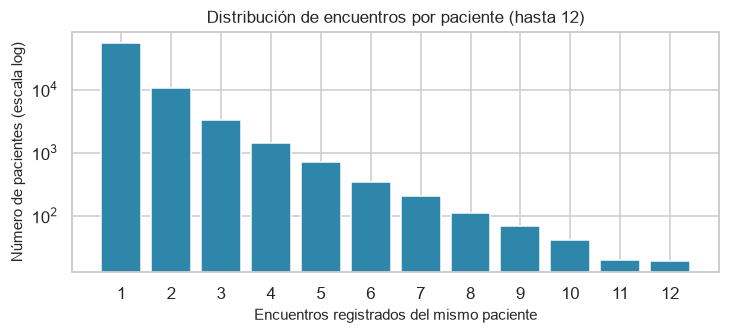

In [18]:
print(f"encounter_id duplicados        : {crudo['encounter_id'].duplicated().sum()}")
print(f"Filas íntegramente duplicadas : {crudo.duplicated().sum()}")

encuentros_por_paciente = crudo["patient_nbr"].value_counts()
print(f"\nPacientes únicos                    : "
      f"{crudo['patient_nbr'].nunique():,}")
print(f"Pacientes con más de un encuentro   : "
      f"{(encuentros_por_paciente > 1).sum():,} "
      f"({100 * (encuentros_por_paciente > 1).mean():.2f} %)")
print(f"Máximo de encuentros de un paciente : {encuentros_por_paciente.max()}")

distribucion = encuentros_por_paciente.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.bar(distribucion.index[:12], distribucion.values[:12], color=PALETA[0])
ax.set_yscale("log")
ax.set_xlabel("Encuentros registrados del mismo paciente")
ax.set_ylabel("Número de pacientes (escala log)")
ax.set_title("Distribución de encuentros por paciente (hasta 12)")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

No hay duplicación en sentido estricto: `encounter_id` es único y no existen filas repetidas. Pero casi uno de cada cuatro pacientes aparece más de una vez, y un paciente llega a registrar hasta 40 encuentros.

Esto tiene una consecuencia directa sobre la validación. Si los encuentros de un mismo paciente se reparten entre entrenamiento y prueba, el modelo puede memorizar rasgos del paciente concreto en lugar de aprender el mecanismo clínico, y la métrica quedaría inflada. Es fuga de información por dependencia de grupo.

Para comprobar que el riesgo es real se ordenan los encuentros de cada paciente y se calcula la tasa de readmisión según la posición del encuentro.

El dataset no incluye fechas de ingreso. Se asume que `encounter_id` es creciente en el tiempo, supuesto habitual en la literatura sobre este conjunto porque el identificador se asigna de forma secuencial al registrar el episodio. El supuesto afecta únicamente a *cuál* encuentro se conserva por paciente, no a cuántos.

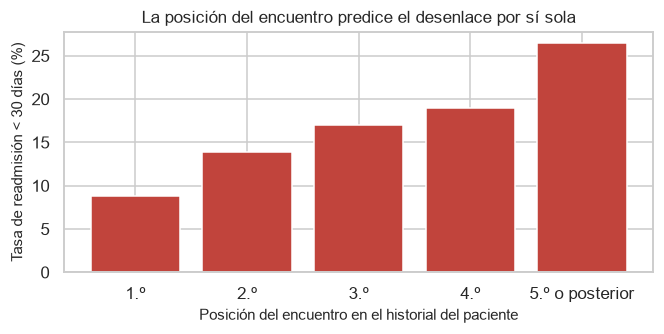

,encuentros,tasa readmisión < 30 días (%)
1.º,71518,8.80
2.º,16773,13.87
3.º,6339,16.99
4.º,3011,18.96
5.º o posterior,4125,26.42


In [20]:
posicion = crudo.sort_values("encounter_id").groupby("patient_nbr").cumcount()

tasa_por_posicion = (
    crudo.assign(posicion=posicion.clip(upper=4),
                 y=(crudo["readmitted"] == "<30").astype(int))
         .groupby("posicion")["y"].agg(["size", "mean"])
)
tasa_por_posicion.index = ["1.º", "2.º", "3.º", "4.º", "5.º o posterior"]
tasa_por_posicion.columns = ["encuentros", "tasa readmisión < 30 días (%)"]
tasa_por_posicion["tasa readmisión < 30 días (%)"] = (
    100 * tasa_por_posicion["tasa readmisión < 30 días (%)"]
).round(2)

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.bar(tasa_por_posicion.index, tasa_por_posicion["tasa readmisión < 30 días (%)"],
       color=PALETA[1])
ax.set_ylabel("Tasa de readmisión < 30 días (%)")
ax.set_xlabel("Posición del encuentro en el historial del paciente")
ax.set_title("La posición del encuentro predice el desenlace por sí sola")
plt.tight_layout()
plt.show()

tasa_por_posicion

La tasa de readmisión temprana crece de forma monótona con el número de encuentros previos: del 9.0 % en el primer encuentro al 23.9 % a partir del cuarto. Es decir, la posición del encuentro en el historial del paciente es por sí sola un predictor fuerte del desenlace.

Un modelo entrenado con todos los encuentros y validado sin agrupar por paciente aprendería parcialmente a reconocer pacientes frecuentes ya vistos, en lugar del riesgo clínico de un paciente nuevo.

### 4.2. Valores faltantes

El análisis se hace sobre los datos **crudos**, porque es la evidencia que fundamenta qué columnas eliminar y cómo tratar el resto.

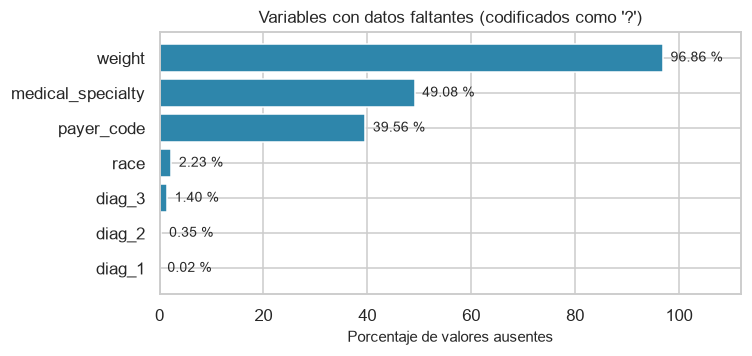

,n_faltantes,%
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [21]:
faltantes = pd.DataFrame({
    "n_faltantes": crudo.isna().sum(),
    "%": (100 * crudo.isna().mean()).round(2),
}).query("n_faltantes > 0").sort_values("%", ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(faltantes.index[::-1], faltantes["%"][::-1], color=PALETA[0])
for i, valor in enumerate(faltantes["%"][::-1]):
    ax.text(valor + 1.5, i, f"{valor:.2f} %", va="center", fontsize=9)
ax.set_xlim(0, 112)
ax.set_xlabel("Porcentaje de valores ausentes")
ax.set_title("Variables con datos faltantes (codificados como '?')")
plt.tight_layout()
plt.show()

faltantes

In [22]:
# Segunda convención: "None" indica prueba no realizada, no dato ausente.
pruebas = pd.DataFrame({
    "no medida ('None') %": [
        100 * (crudo["A1Cresult"] == "None").mean(),
        100 * (crudo["max_glu_serum"] == "None").mean(),
    ],
    "medida %": [
        100 * (crudo["A1Cresult"] != "None").mean(),
        100 * (crudo["max_glu_serum"] != "None").mean(),
    ],
}, index=["A1Cresult", "max_glu_serum"]).round(2)
pruebas

,no medida ('None') %,medida %
A1Cresult,83.28,16.72
max_glu_serum,94.75,5.25


Siete variables presentan faltantes reales, con perfiles muy distintos: `weight` (96.86 %), `medical_specialty` (49.08 %), `payer_code` (39.56 %), `race` (2.23 %) y los tres códigos diagnósticos con ausencias marginales (entre 0.02 % y 1.40 %).

La hemoglobina glicosilada no se midió en el 83 % de los encuentros y la glucosa sérica en el 95 %. Estos valores **no se cuentan como faltantes**, por la razón explicada en la sección 2.

### 4.3. ¿Son aleatorias las ausencias?

La pregunta relevante no es cuántos faltantes hay, sino si su ausencia guarda relación con el desenlace, porque de eso depende el tratamiento correcto. Se contrasta la independencia entre el indicador de faltante y la variable objetivo.

Conviene precisar qué se está probando. Este contraste **no es una prueba de MCAR**: evalúa si la ausencia es independiente del desenlace. Rechazarlo es evidencia contra el supuesto de ausencia completamente aleatoria, pero no lo prueba en sentido estricto, ya que la ausencia podría depender de variables observadas. Además, con n superior a 100,000 cualquier diferencia mínima resulta significativa, de modo que se reporta también la diferencia de tasas como tamaño del efecto.

In [29]:
def correccion_holm(valores_p):
    """Corrección de Holm-Bonferroni para comparaciones múltiples.

    Controla la tasa de error familiar de forma menos conservadora que
    Bonferroni, manteniendo validez sin supuestos sobre la dependencia
    entre contrastes.

    Parameters
    ----------
    valores_p : array_like
        Valores p sin corregir.

    Returns
    -------
    numpy.ndarray
        Valores p ajustados, monótonos y acotados en 1.
    """
    p = np.asarray(valores_p, dtype=float)
    m = len(p)
    orden = np.argsort(p)
    ajustados = np.empty(m)
    maximo = 0.0
    for i, indice in enumerate(orden):
        maximo = max(maximo, (m - i) * p[indice])
        ajustados[indice] = min(1.0, maximo)
    return ajustados


y_crudo = (crudo["readmitted"] == "<30").astype(int)

filas = []
for columna in faltantes.index:
    indicador = crudo[columna].isna().astype(int)
    contingencia = pd.crosstab(indicador, y_crudo)
    chi2, p, _, esperadas = stats.chi2_contingency(contingencia)
    # Con frecuencias esperadas pequeñas la aproximación chi² no es válida:
    # se usa la prueba exacta de Fisher, apropiada en tablas 2x2.
    prueba = "chi²"
    if esperadas.min() < 5:
        p = stats.fisher_exact(contingencia).pvalue
        prueba = "Fisher exacto"
    filas.append({
        "variable": columna,
        "% faltante": 100 * indicador.mean(),
        "prueba": prueba,
        "chi²": chi2,
        "p": p,
        "mín. frecuencia esperada": esperadas.min(),
        "tasa si falta (%)": 100 * y_crudo[indicador == 1].mean(),
        "tasa si está (%)": 100 * y_crudo[indicador == 0].mean(),
    })

nulidad = pd.DataFrame(filas).set_index("variable")
nulidad["p (Holm)"] = correccion_holm(nulidad["p"])
nulidad["diferencia (pp)"] = (
    nulidad["tasa si falta (%)"] - nulidad["tasa si está (%)"]
)
nulidad["¿independiente? (α=0.05)"] = np.where(
    nulidad["p (Holm)"] > 0.05, "Sí", "No"
)
tabla(nulidad.round(4), filas=10)

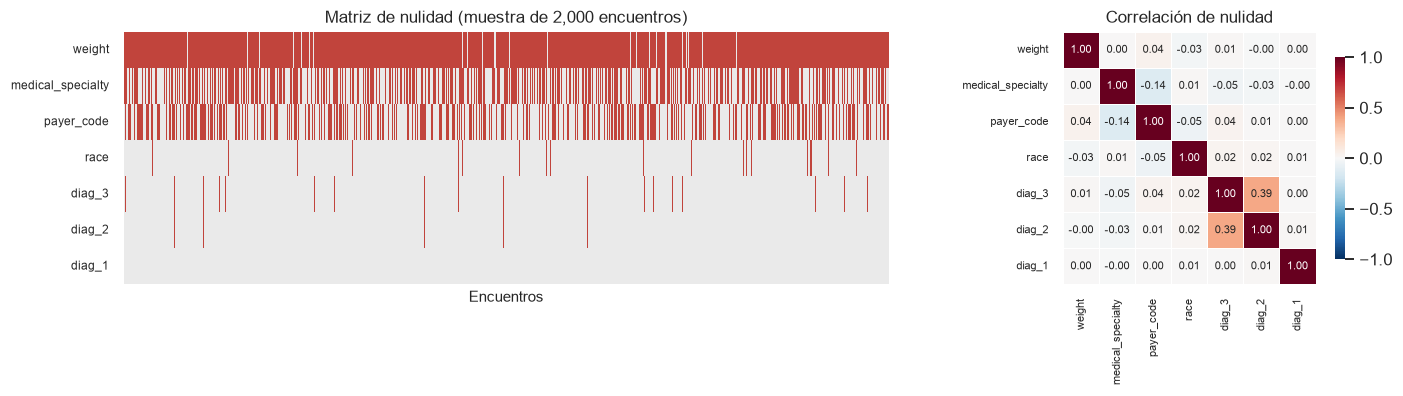

In [30]:
# Coincidencia de ausencias: ¿faltan las mismas filas en varias variables?
columnas_con_faltantes = faltantes.index.tolist()
indicadores = crudo[columnas_con_faltantes].isna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6),
                         gridspec_kw={"width_ratios": [2, 1]})

muestra = indicadores.sample(2000, random_state=RANDOM_STATE)
sns.heatmap(muestra.T, cbar=False, cmap=["#EAEAEA", PALETA[1]],
            yticklabels=True, xticklabels=False, ax=axes[0])
axes[0].set_title("Matriz de nulidad (muestra de 2,000 encuentros)")
axes[0].set_xlabel("Encuentros")
axes[0].tick_params(axis="y", labelsize=8, rotation=0)

correlacion_nulidad = indicadores.corr()
sns.heatmap(correlacion_nulidad, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title("Correlación de nulidad")
axes[1].tick_params(labelsize=7)
plt.tight_layout()
plt.show()

Dos resultados relevantes.

Primero, las ausencias son en su mayoría independientes entre variables, con una excepción: diag_2 y diag_3 correlacionan en 0.39, porque los pacientes con pocos diagnósticos registrados carecen de ambos a la vez. Los demás pares son cercanos a cero, lo que descarta resumir varias ausencias con un único indicador.

Segundo, el patrón respecto al desenlace es heterogéneo. weight es el caso extremo de independencia (chi² nulo, p = 1.00): su ausencia no guarda ninguna relación con la readmisión, lo que refuerza eliminarla sin más consideraciones. medical_specialty, payer_code, race y diag_3 sí rechazan la independencia tras la corrección de Holm, aunque con efectos moderados: entre 0.55 y 4.83 puntos porcentuales de diferencia en la tasa de readmisión. diag_1 y diag_2 no rechazan.

### 4.4. Variables constantes y cuasi constantes

Una variable sin varianza no aporta capacidad discriminante, encarece la codificación y puede producir columnas vacías al aplicar `OneHotEncoder` dentro de un fold de validación.

In [25]:
varianza = pd.DataFrame({
    "categorías": crudo.nunique(),
    "moda": crudo.apply(lambda s: s.value_counts(dropna=False).index[0]),
    "% moda": (100 * crudo.apply(
        lambda s: s.value_counts(dropna=False, normalize=True).iloc[0])).round(3),
})
cuasi_constantes = varianza.query("`% moda` > 95").sort_values(
    "% moda", ascending=False)
tabla(cuasi_constantes, filas=20)

Nueve fármacos superan el 95 % de concentración en una sola categoría. Siete de ellos (`examide`, `citoglipton`, `acetohexamide`, `troglitazone`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`) son estrictamente constantes: todos los pacientes tienen el valor `No`. En `tolbutamide` y `glipizide-metformin` la variación se reduce a una decena de casos, insuficiente para estimar cualquier efecto. Todos se descartan.

### 4.5. Cardinalidad

Las variables con muchas categorías generan matrices dispersas al codificarse y elevan el riesgo de sobreajuste, sobre todo cuando algunas categorías tienen muy pocos casos.

In [26]:
categoricas_crudas = columnas_texto(crudo)
cardinalidad = pd.DataFrame({
    "categorías": crudo[categoricas_crudas].nunique(),
    "% moda": (100 * crudo[categoricas_crudas].apply(
        lambda s: s.value_counts(normalize=True).iloc[0])).round(2),
}).sort_values("categorías", ascending=False)
tabla(cardinalidad, filas=15)

Los tres códigos diagnósticos concentran el problema, con entre 716 y 789 categorías cada uno. Codificarlos directamente produciría más de 2,000 columnas binarias, la mayoría con un puñado de casos. La solución estándar en la literatura sobre este dataset es agruparlos por capítulo de la clasificación ICD-9.

`medical_specialty`, con 72 categorías, presenta un problema más leve que se resuelve agrupando las especialidades poco frecuentes.

### 4.6. Valores inválidos y códigos no informativos

Además de los faltantes explícitos, el dataset contiene categorías que equivalen a información ausente pero están codificadas como valores válidos.

In [27]:
print("Distribución de gender:")
print(crudo["gender"].value_counts().to_string(), "\n")

NO_INFORMATIVOS = {
    "admission_type_id": [5, 6, 8],             # Not Available, NULL, Not Mapped
    "discharge_disposition_id": [18, 25, 26],   # NULL, Not Mapped, Unknown/Invalid
    "admission_source_id": [9, 15, 17, 20, 21],
}
for columna, codigos in NO_INFORMATIVOS.items():
    etiquetas = [mapeos[columna][c] for c in codigos]
    print(f"{columna}: {100 * crudo[columna].isin(codigos).mean():.2f} % "
          f"de los encuentros — {etiquetas}")

Distribución de gender:
gender
Female             54708
Male               47055
Unknown/Invalid        3 

admission_type_id: 10.22 % de los encuentros — ['Not Available', 'NULL', 'Not Mapped']
discharge_disposition_id: 4.60 % de los encuentros — ['NULL', 'Not Mapped', 'Unknown/Invalid']
admission_source_id: 6.94 % de los encuentros — [' Not Available', 'Not Available', 'NULL', ' Not Mapped', 'Unknown/Invalid']


Tres registros tienen `gender` igual a `Unknown/Invalid`. Se eliminan: el volumen es despreciable y no justifica crear una categoría.

Entre el 4.6 % y el 10.2 % de los encuentros tienen códigos administrativos equivalentes a "no disponible" o "no mapeado". Aquí el volumen sí es relevante, de modo que **no se eliminan filas**: esos códigos se conservan como categoría explícita, dado que la ausencia de registro administrativo puede correlacionar con el tipo de institución o con la vía de ingreso.

## 5. Plan de depuración

| # | Decisión | Alcance | Evidencia que la respalda |
|---|---|---|---|
| 1 | Excluir altas por fallecimiento u hospicio (códigos 11, 13, 14, 19, 20, 21) | 2,423 filas | Sección 3: el desenlace es imposible por construcción, no por riesgo clínico |
| 2 | Excluir registros con `gender = Unknown/Invalid` | 3 filas | Sección 4.6: volumen despreciable |
| 3 | Conservar un encuentro por paciente | ~29 % de las filas | Sección 4.1: la posición del encuentro predice el desenlace y genera dependencia entre observaciones |
| 4 | Eliminar `weight` | 1 columna | Sección 4.2: 96.9 % de faltantes; imputar generaría un valor sintético para casi toda la muestra. Su ausencia es además independiente del desenlace (sección 4.3) |
| 5 | Eliminar `payer_code` | 1 columna | Sección 4.2: 39.6 % de faltantes en una variable del asegurador que no describe el estado clínico |
| 6 | Eliminar `encounter_id` | 1 columna | Identificador sin contenido clínico |
| 7 | Eliminar nueve fármacos constantes o cuasi constantes | 9 columnas | Sección 4.4: varianza nula o casi nula |
| 8 | Agrupar los tres códigos ICD-9 por capítulo clínico | 3 columnas | Sección 4.5: cardinalidad de 716 a 789 categorías |
| 9 | Agrupar en `"Otro"` toda categoría con menos del 1 % de los casos, en todas las variables categóricas salvo `race` | 26 columnas | Secciones 4.5 y 4.6: las categorías con muy pocos casos desestabilizan la codificación y violan los supuestos de la prueba chi-cuadrado. `race` queda exenta porque sus categorías ya cumplen los supuestos y agrupar un grupo demográfico minoritario lo eliminaría del análisis de equidad |
| 10 | Categoría explícita: `"No informada"` para `race` y `"No registrada"` para la especialidad médica | 2 columnas | Sección 4.3: la ausencia no es aleatoria y es potencialmente informativa. En el caso de `race` se añade una razón ética: imputar un atributo protegido equivale a fabricar la pertenencia a un grupo |
| 11 | Convertir los tres identificadores administrativos a tipo categórico | 3 columnas | Sección 2: son códigos nominales sin significado ordinal |
| 12 | Derivar `readmitted_30` y eliminar `readmitted` | 1 columna | Sección 1.2 |

### 5.1. Síntesis

| Dimensión | Hallazgo |
|---|---|
| Volumen | 101,766 encuentros, 71,518 pacientes, 50 variables |
| Dependencia entre filas | 23.45 % de los pacientes tiene más de un encuentro; la tasa de readmisión crece del 9.0 % al 23.9 % con la posición del encuentro |
| Convenciones de faltante | Dos distintas: `?` (ausente) y `None` (prueba no realizada, informativo) |
| Faltantes reales | `weight` 96.9 %, `medical_specialty` 49.1 %, `payer_code` 39.6 %, `race` 2.2 %, diagnósticos < 1.5 % |
| Patrón de nulidad | Ausencias mayormente independientes entre variables, salvo `diag_2` y `diag_3` (correlación 0.39). Cuatro variables rechazan la independencia respecto al desenlace, con diferencias de 0.55 a 4.83 puntos porcentuales; `weight`, `diag_1` y `diag_2` no la rechazan |
| Varianza | Nueve fármacos constantes o cuasi constantes |
| Cardinalidad | Diagnósticos con 716 a 789 categorías; especialidad médica con 72 |
| Valores inválidos | 3 registros con género inválido; entre 4.6 % y 10.2 % de códigos administrativos no informativos |
| Rangos | Sin valores negativos, imposibles ni códigos centinela |